In [269]:
#import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score


In [270]:
# Load the synthetic dataset
df = pd.read_csv('synthetic_T1_diabetes_data.csv')

# Quick check
df.head()


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness,Condition
0,9.0,2.5,5,17,44,0,0,1,0,1,1,0
1,20.0,2.5,15,18,98,0,1,1,0,1,1,0
2,5.9,2.5,3,20,26,0,0,1,0,1,1,0
3,7.0,3.7,3,14,16,0,0,0,0,1,1,0
4,15.2,2.8,9,11,63,0,0,1,0,1,1,0


In [271]:

# Map numeric labels to condition names
condition_map = {0: "Hypoglycemia", 1: "Normal", 2: "Hyperglycemia", 3: "DKA"}
y = df['Condition']

# Unique numeric labels
unique_labels = y.unique()
print("Unique numeric labels:", unique_labels)

# Unique condition names
unique_conditions = [condition_map[label] for label in unique_labels]
print("Unique conditions:", unique_conditions)


Unique numeric labels: [0 1 2 3]
Unique conditions: ['Hypoglycemia', 'Normal', 'Hyperglycemia', 'DKA']


C:\Users\Blessing\AppData\Local\Temp\ipykernel_20032\3109872007.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Condition', data=df, order=sorted(df['Condition'].unique()), palette='viridis')


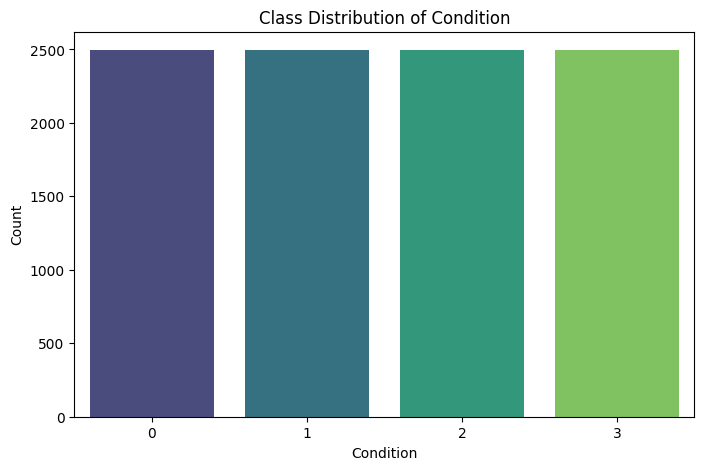

In [272]:
# Visualize class distribution

plt.figure(figsize=(8,5))
sns.countplot(x='Condition', data=df, order=sorted(df['Condition'].unique()), palette='viridis')
plt.title('Class Distribution of Condition')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.show()


In [273]:
# Features (all columns except 'Condition')
X = df.drop('Condition', axis=1)

# Labels (Condition column)
y = df['Condition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [274]:
# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [275]:
# Read the CSV using tab separator
real_df = pd.read_csv('real_data.csv', sep='\t')

# Check column names
print(real_df.columns)

# Check column names

print("Columns in file:\n", real_df.columns.tolist())


Index(['ID', 'Time', 'Record Type', 'Historic Glucose (mmol/L)',
       'Scan Glucose (mmol/L)', 'Non-numeric Rapid-Acting Insulin',
       'Rapid-Acting Insulin (units)', 'Non-numeric Food',
       'Carbohydrates (grams)', 'Non-numeric Long-Acting Insulin',
       'Long-Acting Insulin (units)', 'Notes', 'Strip Glucose (mmol/L)',
       'Ketone (mmol/L)', 'Meal Insulin (units)', 'Correction Insulin (units)',
       'User Change Insulin (units)', 'Previous Time', 'Updated Time'],
      dtype='str')
Columns in file:
 ['ID', 'Time', 'Record Type', 'Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Non-numeric Rapid-Acting Insulin', 'Rapid-Acting Insulin (units)', 'Non-numeric Food', 'Carbohydrates (grams)', 'Non-numeric Long-Acting Insulin', 'Long-Acting Insulin (units)', 'Notes', 'Strip Glucose (mmol/L)', 'Ketone (mmol/L)', 'Meal Insulin (units)', 'Correction Insulin (units)', 'User Change Insulin (units)', 'Previous Time', 'Updated Time']


In [276]:
# Select only columns relevant to the model
needed_cols = [
    'Historic Glucose (mmol/L)',
    'Scan Glucose (mmol/L)',
    'Rapid-Acting Insulin (units)',
    'Long-Acting Insulin (units)',
    'Carbohydrates (grams)'
]

# Keep only required columns
real_df = real_df[needed_cols]

# Check for missing values
print("Missing values before filling:\n", real_df.isnull().sum())


Missing values before filling:
 Historic Glucose (mmol/L)        1676
Scan Glucose (mmol/L)           11632
Rapid-Acting Insulin (units)    12788
Long-Acting Insulin (units)     12920
Carbohydrates (grams)           12781
dtype: int64


In [277]:
#  — Clean and replace zeros with median value
import numpy as np

# Replace zeros with NaN for easy processing
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].replace(0, np.nan)

# Compute median of valid values
median_glucose = real_df['Historic Glucose (mmol/L)'].median()

# Fill missing values with median
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].fillna(median_glucose)

print(" Historic Glucose cleaned — zeros replaced with median value:", median_glucose)


 Historic Glucose cleaned — zeros replaced with median value: 7.7


In [278]:
#  — Fix Scan Glucose zeros using Historic Glucose or median
# Replace NaN or 0 values in Scan Glucose
median_scan = real_df['Scan Glucose (mmol/L)'].median()

# First fill zeros or NaN using Historic Glucose
real_df['Scan Glucose (mmol/L)'] = real_df.apply(
    lambda row: row['Historic Glucose (mmol/L)']
    if pd.isna(row['Scan Glucose (mmol/L)']) or row['Scan Glucose (mmol/L)'] == 0
    else row['Scan Glucose (mmol/L)'],
    axis=1
)

# Fill any remaining NaN or 0 with the median
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].replace(0, median_scan)
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].fillna(median_scan)

print(" Scan Glucose fully cleaned — no NaNs or zeros remain!")
print(real_df['Scan Glucose (mmol/L)'].isna().sum(), "missing values remain")


# Confirm fix
print(" Scan Glucose cleaned — summary:")
print(real_df[['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)']].describe())


 Scan Glucose fully cleaned — no NaNs or zeros remain!
0 missing values remain
 Scan Glucose cleaned — summary:
       Historic Glucose (mmol/L)  Scan Glucose (mmol/L)
count               12949.000000           12949.000000
mean                    8.085667               8.197081
std                     2.866533               3.027733
min                     2.200000               2.200000
25%                     6.200000               6.000000
50%                     7.700000               7.700000
75%                     9.600000              10.000000
max                    24.200000              24.200000


In [279]:
# Final check: fill any new NaNs after combining Scan and Historic
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].fillna(
    real_df['Historic Glucose (mmol/L)'].median()
)
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].fillna(
    real_df['Scan Glucose (mmol/L)'].median()
)

print("Final glucose cleaning done — no NaNs remain.")


Final glucose cleaning done — no NaNs remain.


In [280]:
#FEATURE ENGINEERING: ASSIGN SYMPTOMS BASED ON GLUCOSE LEVELS

# Create symptom columns initialized to 0
symptom_cols = ['Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
for col in symptom_cols:
    real_df[col] = 0

# Apply logic based on glucose levels
for i, row in real_df.iterrows():
    glucose = row['Scan Glucose (mmol/L)']
    
    # Hypoglycemia (<4.0)
    if glucose < 4.0:
        real_df.at[i, 'Shakiness'] = 1
        real_df.at[i, 'Weakness'] = 1
        real_df.at[i, 'Fatigue'] = 1
    
    # NORMAL RANGE (4.0-7.0)
    elif 4.0 <= glucose < 7.0:
        # Borderline low (4.0-5.0) might have mild
        if glucose < 5.0:
            real_df.at[i, 'Shakiness'] = 1
        # # Borderline high normal: Mild fatigue for mid-normal
        elif glucose > 6.5:
            real_df.at[i, 'Fatigue'] = 1
    
    # Hyperglycemia (7.0-12.0) 
    elif 7.0 <= glucose < 12.0: 
        real_df.at[i, 'Thirst'] = 1
        real_df.at[i, 'Fatigue'] = 1
        # Add Nausea for higher hyperglycemia
        if glucose >= 10.0:
            real_df.at[i, 'Nausea'] = 1
        # Weakness may appear in upper hyperglycemia
        if glucose >= 11.0:
            real_df.at[i, 'Weakness'] = 1
    
    # DKA (≥12.0)
    elif glucose >= 12.0: 
        real_df.at[i, 'Thirst'] = 1
        real_df.at[i, 'Nausea'] = 1
        real_df.at[i, 'Vomiting'] = 1
        real_df.at[i, 'Fatigue'] = 1
        real_df.at[i, 'Weakness'] = 1

print("Symptoms assigned successfully!")
print("\nSample data:")
print(real_df[['Scan Glucose (mmol/L)', 'Shakiness', 'Thirst', 'Fatigue', 'Weakness', 'Nausea', 'Vomiting']].head())


Symptoms assigned successfully!

Sample data:
   Scan Glucose (mmol/L)  Shakiness  Thirst  Fatigue  Weakness  Nausea  \
0                    8.8          0       1        1         0       0   
1                   10.4          0       1        1         0       1   
2                    7.7          0       1        1         0       0   
3                   14.2          0       1        1         1       1   
4                   14.5          0       1        1         1       1   

   Vomiting  
0         0  
1         0  
2         0  
3         1  
4         1  


In [281]:
# Show the updated dataframe with all important columns
print("Final cleaned and symptom-augmented dataset:\n")
real_df[
    [
        'Historic Glucose (mmol/L)',
        'Scan Glucose (mmol/L)',
        'Rapid-Acting Insulin (units)',
        'Long-Acting Insulin (units)',
        'Carbohydrates (grams)',
        'Thirst',
        'Nausea',
        'Weakness',
        'Vomiting',
        'Fatigue',
        'Shakiness'
    ]
].head(20) 


Final cleaned and symptom-augmented dataset:



,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,NaN,NaN,NaN,1,0,0,0,1,0
1,7.7,10.4,NaN,NaN,NaN,1,1,0,0,1,0
2,7.7,7.7,2.0,NaN,NaN,1,0,0,0,1,0
3,7.7,14.2,NaN,NaN,NaN,1,1,1,1,1,0
4,7.7,14.5,NaN,NaN,NaN,1,1,1,1,1,0
5,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0
6,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0
7,7.7,7.7,NaN,12.0,NaN,1,0,0,0,1,0
8,7.7,6.8,NaN,NaN,NaN,0,0,0,0,1,0
9,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0


In [282]:
#  — Arrange columns in the same order as training
feature_cols = [
    'Historic Glucose (mmol/L)',
    'Scan Glucose (mmol/L)',
    'Rapid-Acting Insulin (units)',
    'Long-Acting Insulin (units)',
    'Carbohydrates (grams)'
] + symptom_cols

real_df = real_df[feature_cols]

print(" Final dataset ready for prediction:")
display(real_df.head())


 Final dataset ready for prediction:


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,NaN,NaN,NaN,1,0,0,0,1,0
1,7.7,10.4,NaN,NaN,NaN,1,1,0,0,1,0
2,7.7,7.7,2.0,NaN,NaN,1,0,0,0,1,0
3,7.7,14.2,NaN,NaN,NaN,1,1,1,1,1,0
4,7.7,14.5,NaN,NaN,NaN,1,1,1,1,1,0


In [283]:
# Fill insulin and carb NaNs with 0 (means no dose or no meal)
real_df['Rapid-Acting Insulin (units)'] = real_df['Rapid-Acting Insulin (units)'].fillna(0)
real_df['Long-Acting Insulin (units)'] = real_df['Long-Acting Insulin (units)'].fillna(0)
real_df['Carbohydrates (grams)'] = real_df['Carbohydrates (grams)'].fillna(0)


print("Missing values after cleaning:\n", real_df.isnull().sum())
real_df.head()

Missing values after cleaning:
 Historic Glucose (mmol/L)       0
Scan Glucose (mmol/L)           0
Rapid-Acting Insulin (units)    0
Long-Acting Insulin (units)     0
Carbohydrates (grams)           0
Thirst                          0
Nausea                          0
Weakness                        0
Vomiting                        0
Fatigue                         0
Shakiness                       0
dtype: int64


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,0.0,0.0,0.0,1,0,0,0,1,0
1,7.7,10.4,0.0,0.0,0.0,1,1,0,0,1,0
2,7.7,7.7,2.0,0.0,0.0,1,0,0,0,1,0
3,7.7,14.2,0.0,0.0,0.0,1,1,1,1,1,0
4,7.7,14.5,0.0,0.0,0.0,1,1,1,1,1,0


In [284]:
# Condition assignment function with updated glucose ranges and soft symptom influence


def assign_condition(glucose, thirst, nausea, vomiting, weakness, fatigue, shakiness):
    """
    Clinically aligned condition assignment with soft symptom influence.
    Uses updated glucose ranges from the synthetic generator:
        Hypo: <4.0
        Normal: 4.0–7.0
        Hyper: 7.0–12.0
        DKA: ≥12.0
    Symptom influence is incorporated for borderline cases.
    """

    # Fixed thresholds: fixed glucose level boundaries (in mmol/L) for different metabolic states, based on clinical ranges used in T1D
    hypo_threshold = 4.0
    normal_upper = 7.0
    hyper_upper = 12.0
    dka_threshold = 12.0

    # Base glucose classification: gives an initial health state based on glucose level alone.
    if glucose < hypo_threshold:
        base_condition = 0  # Hypoglycemia
    elif glucose < normal_upper:
        base_condition = 1  # Normal
    elif glucose < hyper_upper:
        base_condition = 2  # Hyperglycemia
    else:
        base_condition = 3  # DKA


    # Soft Symptom Influence
    
    symptom_score = thirst + nausea + vomiting + weakness + fatigue + shakiness

    # Borderline Hypo/Normal (4.0–5.0)
    if 4.0 <= glucose <= 5.0:
        if symptom_score >= 2:
            return 0  # Lean Hypoglycemia
        elif symptom_score <= 1:
            return 1  # Normal
        else:
            return base_condition

    # Borderline Normal/Hyper (6.5–7.5)
    if 6.5 <= glucose <= 7.5:
        if symptom_score >= 2:
            return 2  # Slight Hyperglycemia
        elif symptom_score <= 1:
            return 1  # Normal
        else:
            return base_condition

    # Borderline Hyper/DKA (11.5–12.5)
    if 11.5 <= glucose <= 12.5:
        if symptom_score >= 4:
            return 3  # DKA
        elif symptom_score <= 2:
            return 2  # Hyperglycemia
        else:
            return base_condition

    # Severe symptom override
    if glucose >= 10.0 and symptom_score >= 5:
        return 3  # Clinical DKA

    # Default return
    return base_condition


# Apply to real data
print("Assigning conditions to real data (with updated glucose ranges and soft symptom weighting)...")
real_df['Condition'] = real_df.apply(
    lambda row: assign_condition(
        row['Scan Glucose (mmol/L)'],
        row['Thirst'],
        row['Nausea'],
        row['Vomiting'],
        row['Weakness'],
        row['Fatigue'],
        row['Shakiness']
    ),
    axis=1
)

print("Conditions assigned successfully!")
print("\nCondition distribution in real data:")
print(real_df['Condition'].value_counts().sort_index())


Assigning conditions to real data (with updated glucose ranges and soft symptom weighting)...
Conditions assigned successfully!

Condition distribution in real data:
Condition
0     660
1    4238
2    6207
3    1844
Name: count, dtype: int64


In [285]:
# Balance the dataset by downsampling to the smallest class size: Each condition contributes equally to performance metrics.Also,we fairly evaluate how the model performs across all classes.

from collections import Counter

# Check current distribution
print("Original class distribution:")
print(real_df['Condition'].value_counts().sort_index())

# find minimum class size
class_counts = Counter(real_df['Condition'])
min_samples = min(class_counts.values())

print(f"\nBalancing to minimum class size: {min_samples} samples per class")

# Balance the dataset by sampling
balanced_dfs = []
for condition_class in range(4):
    class_df = real_df[real_df['Condition'] == condition_class]
    
    if len(class_df) >= min_samples:
        sampled = class_df.sample(min_samples, random_state=42)
    else:
        print(f" Warning: Class {condition_class} has only {len(class_df)} samples")
        sampled = class_df  # Use all available
    
    balanced_dfs.append(sampled)

balanced_real_df = pd.concat(balanced_dfs, ignore_index=True)
print(f"\nBalanced dataset size: {len(balanced_real_df)}")
print("\nBalanced class distribution:")
print(balanced_real_df['Condition'].value_counts().sort_index())

Original class distribution:
Condition
0     660
1    4238
2    6207
3    1844
Name: count, dtype: int64

Balancing to minimum class size: 660 samples per class

Balanced dataset size: 2640

Balanced class distribution:
Condition
0    660
1    660
2    660
3    660
Name: count, dtype: int64


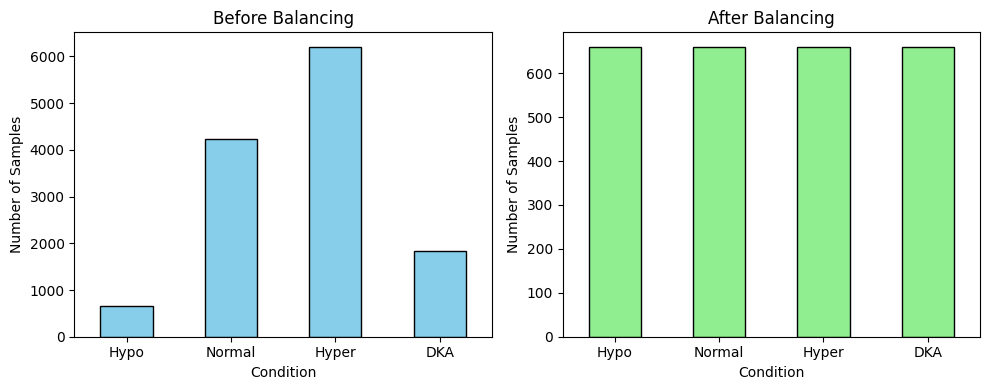

In [286]:
# Visualize class distribution before and after balancing

import matplotlib.pyplot as plt

# Plot before balancing
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
real_df['Condition'].value_counts().sort_index().plot(
    kind='bar', color='skyblue', edgecolor='black'
)
plt.title('Before Balancing')
plt.xlabel('Condition')
plt.ylabel('Number of Samples')
plt.xticks([0, 1, 2, 3], ['Hypo', 'Normal', 'Hyper', 'DKA'], rotation=0)

# Plot after balancing
plt.subplot(1, 2, 2)
balanced_real_df['Condition'].value_counts().sort_index().plot(
    kind='bar', color='lightgreen', edgecolor='black'
)
plt.title('After Balancing')
plt.xlabel('Condition')
plt.ylabel('Number of Samples')
plt.xticks([0, 1, 2, 3], ['Hypo', 'Normal', 'Hyper', 'DKA'], rotation=0)

plt.tight_layout()
plt.show()


In [287]:


# Ensure columns match training data exactly
X_real = balanced_real_df[X_train.columns]  # Use X_train columns order
y_true = balanced_real_df['Condition']

# Verify
print("Training features:", X_train.columns.tolist())
print("Real data features:", X_real.columns.tolist())
print("Features match:", list(X_train.columns) == list(X_real.columns))
print("\nMissing values:", X_real.isnull().sum().sum())
print(f"\nReal data samples: {len(X_real)}")
print(f"Real labels samples: {len(y_true)}")

Training features: ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)', 'Carbohydrates (grams)', 'Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
Real data features: ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)', 'Carbohydrates (grams)', 'Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
Features match: True

Missing values: 0

Real data samples: 2640
Real labels samples: 2640


Training Random Forest model...
Training complete!
Random Forest Model Accuracy on Real Data: 0.9769

Classification Report:
               precision    recall  f1-score   support

        Hypo       1.00      1.00      1.00       660
      Normal       1.00      1.00      1.00       660
       Hyper       0.92      1.00      0.96       660
         DKA       1.00      0.91      0.95       660

    accuracy                           0.98      2640
   macro avg       0.98      0.98      0.98      2640
weighted avg       0.98      0.98      0.98      2640



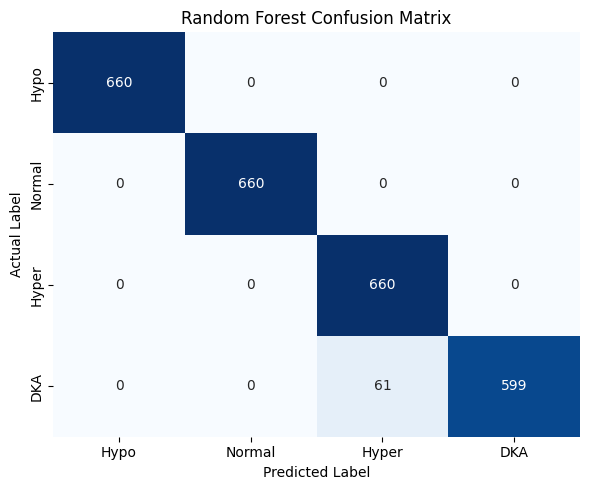


# Note: Handles non-linear data well, robust to overfitting with enough trees.


In [288]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Train Random Forest on synthetic data
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Training complete!")

# Predict on balanced real data
y_pred_real_rf = rf_model.predict(X_real)

# Evaluate on real data
accuracy_rf = accuracy_score(y_true, y_pred_real_rf)
print(f"Random Forest Model Accuracy on Real Data: {accuracy_rf:.4f}")

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred_real_rf,
                                                         target_names=['Hypo', 'Normal', 'Hyper', 'DKA']))

# Confusion Matrix
cm_rf = confusion_matrix(y_true, y_pred_real_rf)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Hypo', 'Normal', 'Hyper', 'DKA'],
            yticklabels=['Hypo', 'Normal', 'Hyper', 'DKA'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

print("\n# Note: Handles non-linear data well, robust to overfitting with enough trees.")

In [289]:
# Compare glucose ranges
print("Synthetic data glucose range:", df['Scan Glucose (mmol/L)'].describe())
print("Real data glucose range:", real_df['Scan Glucose (mmol/L)'].describe())


Synthetic data glucose range: count    9984.000000
mean        8.912433
std         6.392002
min         2.500000
25%         3.975000
50%         6.950000
75%        11.880217
max        23.999120
Name: Scan Glucose (mmol/L), dtype: float64
Real data glucose range: count    12949.000000
mean         8.197081
std          3.027733
min          2.200000
25%          6.000000
50%          7.700000
75%         10.000000
max         24.200000
Name: Scan Glucose (mmol/L), dtype: float64


FEATURE IMPORTANCE ANALYSIS

Feature Importance Ranking:
                     Feature  Importance
       Scan Glucose (mmol/L)    0.468318
                   Shakiness    0.154404
                    Vomiting    0.077608
                      Thirst    0.065134
                      Nausea    0.051516
                     Fatigue    0.050195
       Carbohydrates (grams)    0.044806
                    Weakness    0.038400
   Historic Glucose (mmol/L)    0.028492
Rapid-Acting Insulin (units)    0.016265
 Long-Acting Insulin (units)    0.004861


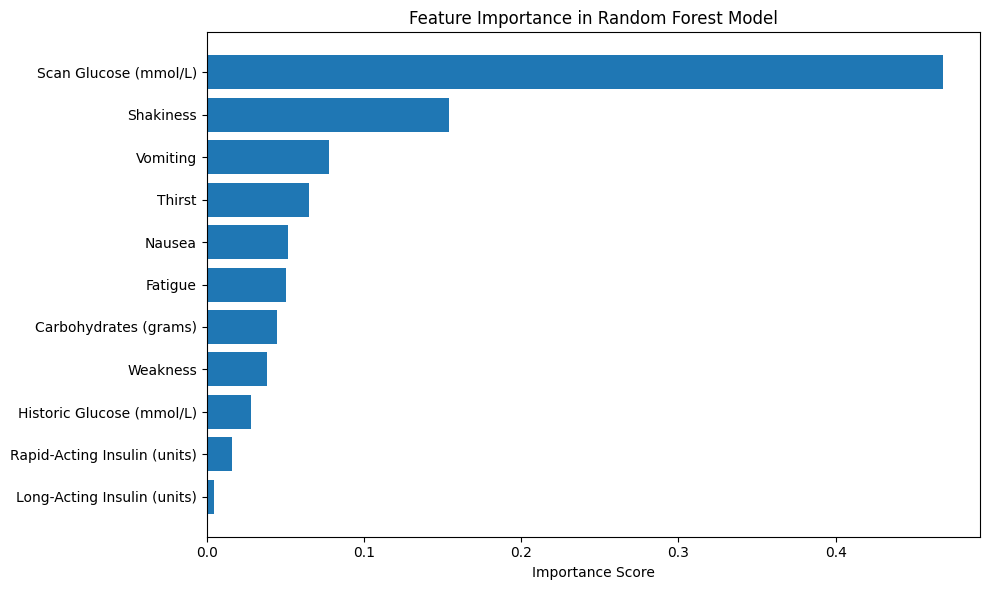

In [290]:

#  FEATURE IMPORTANCE ANALYSIS

print("FEATURE IMPORTANCE ANALYSIS")

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [291]:

#  BASELINE MODEL PERFORMANCE


print(" BASELINE MODEL PERFORMANCE")


# Test set performance: how well your model learned from synthetic patterns.
y_pred_test = rf_model.predict(X_test)
baseline_test_acc = accuracy_score(y_test, y_pred_test)
print(f"\nTest Set Accuracy (All Features): {baseline_test_acc:.4f}")

# Real data performance: how well it transfers that learning to actual patient data.
y_pred_real = rf_model.predict(X_real)
baseline_real_acc = accuracy_score(y_true, y_pred_real)
print(f"Real Data Accuracy (All Features): {baseline_real_acc:.4f}")

 BASELINE MODEL PERFORMANCE

Test Set Accuracy (All Features): 0.9995
Real Data Accuracy (All Features): 0.9769


 ABLATION STUDY - REMOVING ONE FEATURE AT A TIME

 Testing WITHOUT: Historic Glucose (mmol/L)


   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9580 (Impact: +0.0189)

 Testing WITHOUT: Scan Glucose (mmol/L)
   Test Accuracy: 0.9184 (Impact: +0.0811)
   Real Accuracy: 0.8587 (Impact: +0.1182)

 Testing WITHOUT: Rapid-Acting Insulin (units)
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9769 (Impact: +0.0000)

 Testing WITHOUT: Long-Acting Insulin (units)
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9580 (Impact: +0.0189)

 Testing WITHOUT: Carbohydrates (grams)
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9955 (Impact: -0.0186)

 Testing WITHOUT: Thirst
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9928 (Impact: -0.0159)

 Testing WITHOUT: Nausea
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.8958 (Impact: +0.0811)

 Testing WITHOUT: Weakness
   Test Accuracy: 0.9990 (Impact: +0.0005)
   Real Accuracy: 0.9848 (Impact: -0.0080)

 Testing WITHOUT: Vomiting
   Test Accuracy: 0.9995 (I

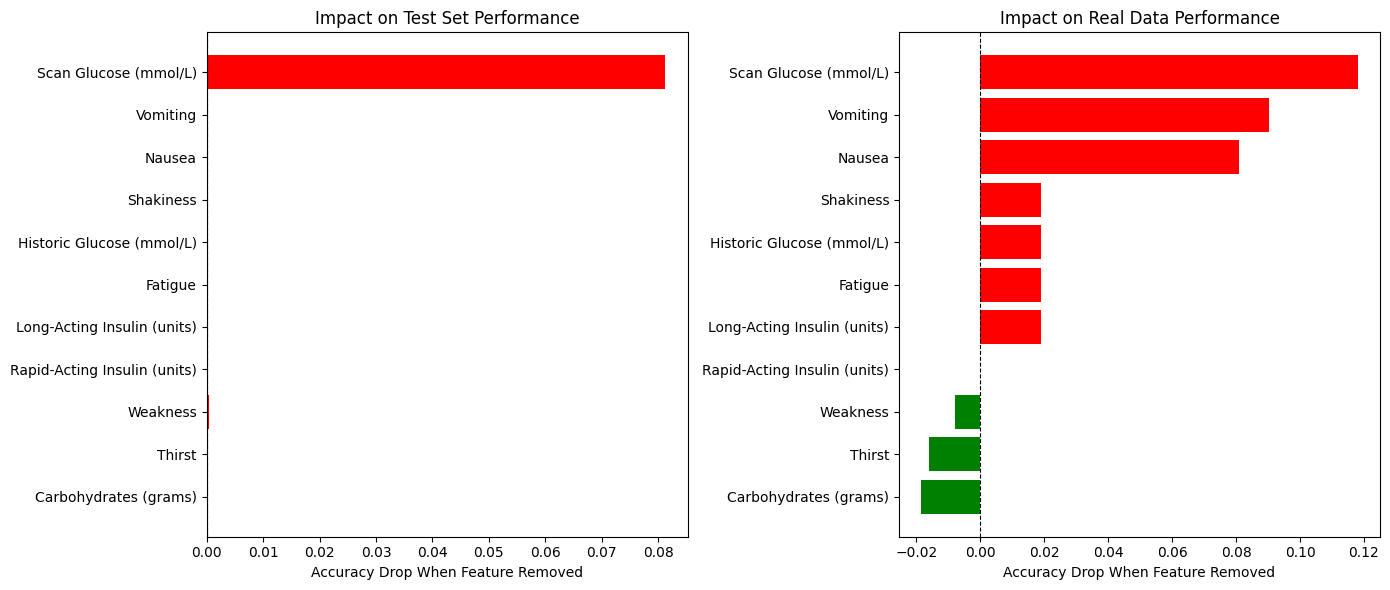

In [292]:

#  ABLATION STUDY - Remove One Feature at a Time


print(" ABLATION STUDY - REMOVING ONE FEATURE AT A TIME")


ablation_results = []

# Loop through each feature
for feature in X_train.columns:
    print(f"\n Testing WITHOUT: {feature}")
    
    # Create dataset without this feature
    X_train_ablated = X_train.drop(columns=[feature])
    X_test_ablated = X_test.drop(columns=[feature])
    X_real_ablated = X_real.drop(columns=[feature])
    
    # Train new model
    model_ablated = RandomForestClassifier(n_estimators=100, random_state=42)
    model_ablated.fit(X_train_ablated, y_train)
    
    # Test performance : synthetic test set
    y_pred_test_ablated = model_ablated.predict(X_test_ablated)
    test_acc = accuracy_score(y_test, y_pred_test_ablated)

    # Real data performance : how well it transfers that learning to actual patient data.
    y_pred_real_ablated = model_ablated.predict(X_real_ablated)
    real_acc = accuracy_score(y_true, y_pred_real_ablated)
    
    # Calculate impact
    test_impact = baseline_test_acc - test_acc
    real_impact = baseline_real_acc - real_acc
    
    ablation_results.append({
        'Removed Feature': feature,
        'Test Accuracy': test_acc,
        'Test Impact': test_impact,
        'Real Accuracy': real_acc,
        'Real Impact': real_impact
    })
    
    print(f"   Test Accuracy: {test_acc:.4f} (Impact: {test_impact:+.4f})")
    print(f"   Real Accuracy: {real_acc:.4f} (Impact: {real_impact:+.4f})")

# Convert to DataFrame
ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.sort_values('Real Impact', ascending=False)

print("ABLATION STUDY SUMMARY (Sorted by Real Data Impact)")
print(ablation_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Test set impact
axes[0].barh(ablation_df['Removed Feature'], ablation_df['Test Impact'], 
             color=['red' if x > 0 else 'green' for x in ablation_df['Test Impact']])
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Accuracy Drop When Feature Removed')
axes[0].set_title('Impact on Test Set Performance')
axes[0].invert_yaxis()

# Real data impact
axes[1].barh(ablation_df['Removed Feature'], ablation_df['Real Impact'],
             color=['red' if x > 0 else 'green' for x in ablation_df['Real Impact']])
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Accuracy Drop When Feature Removed')
axes[1].set_title('Impact on Real Data Performance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [293]:
# After your ablation loop
print("INTERPRETATION GUIDE:")
print(" Impact > +2%:  Critical feature")
print(" Impact +0.5% to +2%:  Helpful feature")
print(" Impact -0.5% to +0.5%:  Negligible/redundant feature")
print(" Impact < -2%:  Harmful feature (investigate!)")

# Categorize features
critical = ablation_df[ablation_df['Real Impact'] > 0.02]
helpful = ablation_df[(ablation_df['Real Impact'] > 0.005) & (ablation_df['Real Impact'] <= 0.02)]
negligible = ablation_df[(ablation_df['Real Impact'] >= -0.005) & (ablation_df['Real Impact'] <= 0.005)]

print(f"\nCritical features: {len(critical)}")
print(critical['Removed Feature'].tolist())

print(f"\nHelpful features: {len(helpful)}")
print(helpful['Removed Feature'].tolist())

print(f"\nNegligible/Redundant features: {len(negligible)}")
print(negligible['Removed Feature'].tolist())

INTERPRETATION GUIDE:
 Impact > +2%:  Critical feature
 Impact +0.5% to +2%:  Helpful feature
 Impact -0.5% to +0.5%:  Negligible/redundant feature
 Impact < -2%:  Harmful feature (investigate!)

Critical features: 3
['Scan Glucose (mmol/L)', 'Vomiting', 'Nausea']

Helpful features: 4
['Shakiness', 'Historic Glucose (mmol/L)', 'Fatigue', 'Long-Acting Insulin (units)']

Negligible/Redundant features: 1
['Rapid-Acting Insulin (units)']


In [294]:

#  FEATURE GROUP ANALYSIS - how well different categories of features perform when used together


print("FEATURE GROUP ANALYSIS")


feature_groups = {
    'Glucose Only': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)'],
    'Insulin Only': ['Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)'],
    'Carbs Only': ['Carbohydrates (grams)'],
    'Symptoms Only': ['Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness'],
    'Glucose + Insulin': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 
                          'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)'],
    'No Symptoms': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)',
                    'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)',
                    'Carbohydrates (grams)']
}

group_results = []

#loop through each feature group
for group_name, features in feature_groups.items():
    print(f"\n Testing with: {group_name}")
    
    # Select only these features
    X_train_group = X_train[features]
    X_test_group = X_test[features]
    X_real_group = X_real[features]
    
    # Train model
    model_group = RandomForestClassifier(n_estimators=100, random_state=42)
    model_group.fit(X_train_group, y_train)
    
    # Evaluate
    test_acc = accuracy_score(y_test, model_group.predict(X_test_group))
    real_acc = accuracy_score(y_true, model_group.predict(X_real_group))
    
    group_results.append({
        'Feature Group': group_name,
        'Num Features': len(features),
        'Test Accuracy': test_acc,
        'Real Accuracy': real_acc
    })
    
    print(f"   Test Accuracy: {test_acc:.4f}")
    print(f"   Real Accuracy: {real_acc:.4f}")

# Display results
group_df = pd.DataFrame(group_results)
group_df = group_df.sort_values('Real Accuracy', ascending=False)

print("FEATURE GROUP COMPARISON")

print(group_df.to_string(index=False))

FEATURE GROUP ANALYSIS

 Testing with: Glucose Only
   Test Accuracy: 0.9995
   Real Accuracy: 0.8867

 Testing with: Insulin Only
   Test Accuracy: 0.5303
   Real Accuracy: 0.2500

 Testing with: Carbs Only
   Test Accuracy: 0.5458
   Real Accuracy: 0.2458

 Testing with: Symptoms Only
   Test Accuracy: 0.8353
   Real Accuracy: 0.8909

 Testing with: Glucose + Insulin
   Test Accuracy: 0.9995
   Real Accuracy: 0.9072

 Testing with: No Symptoms
   Test Accuracy: 0.9995
   Real Accuracy: 0.8867
FEATURE GROUP COMPARISON
    Feature Group  Num Features  Test Accuracy  Real Accuracy
Glucose + Insulin             4       0.999499       0.907197
    Symptoms Only             6       0.835253       0.890909
      No Symptoms             5       0.999499       0.886742
     Glucose Only             2       0.999499       0.886742
     Insulin Only             2       0.530295       0.250000
       Carbs Only             1       0.545819       0.245833


 FEATURE CORRELATION ANALYSIS


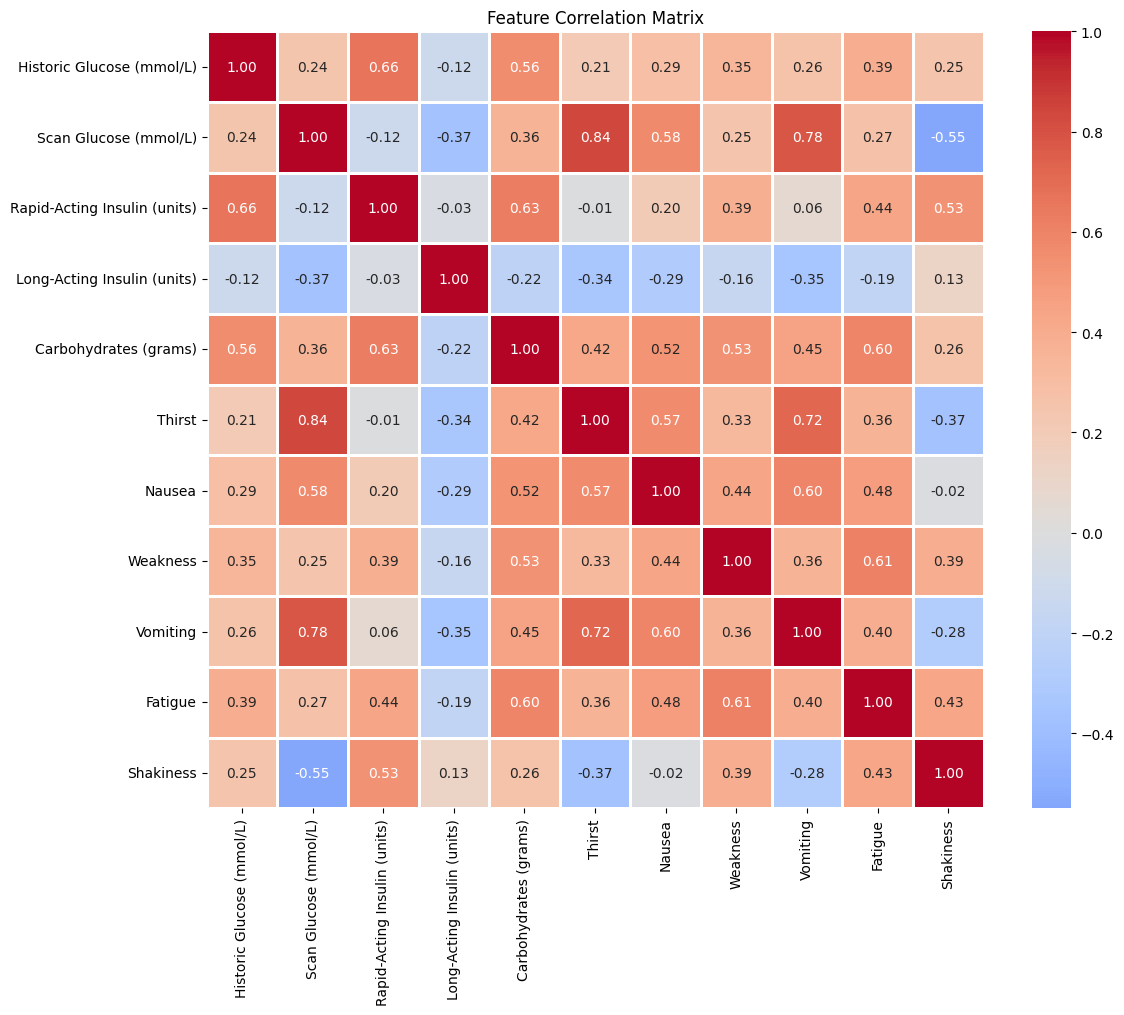

In [295]:

#  FEATURE CORRELATION ANALYSIS

print(" FEATURE CORRELATION ANALYSIS")


# Calculate correlation matrix
correlation_matrix = X_train.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

TRAINING: XGBoost
Training XGBoost model...
Training complete!
XGBoost Model Accuracy on Real Data: 0.9962

Classification Report:
               precision    recall  f1-score   support

        Hypo       1.00      1.00      1.00       660
      Normal       1.00      1.00      1.00       660
       Hyper       0.99      1.00      0.99       660
         DKA       1.00      0.98      0.99       660

    accuracy                           1.00      2640
   macro avg       1.00      1.00      1.00      2640
weighted avg       1.00      1.00      1.00      2640



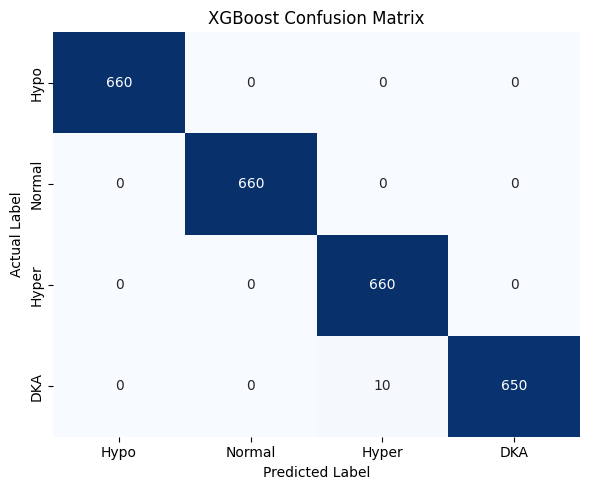


# Note: Effective for structured/tabular data, handles missing values, and supports regularization.


In [296]:

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("TRAINING: XGBoost")

# Calculate class weights for XGBoost
class_counts = np.bincount(y_train)
class_weights = len(y_train) / (len(class_counts) * class_counts)
sample_weights = np.array([class_weights[int(y)] for y in y_train])

# Train XGBoost on synthetic data
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

print("Training XGBoost model...")
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
print("Training complete!")

# Predict on balanced real data
y_pred_test_xgb = xgb_model.predict(X_test)
y_pred_real_xgb = xgb_model.predict(X_real)

# Evaluate on real data
accuracy_xgb = accuracy_score(y_true, y_pred_real_xgb)
print(f"XGBoost Model Accuracy on Real Data: {accuracy_xgb:.4f}")

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred_real_xgb,
                                                         target_names=['Hypo', 'Normal', 'Hyper', 'DKA']))

# Confusion Matrix
cm_xgb = confusion_matrix(y_true, y_pred_real_xgb)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Hypo', 'Normal', 'Hyper', 'DKA'],
            yticklabels=['Hypo', 'Normal', 'Hyper', 'DKA'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

print("\n# Note: Effective for structured/tabular data, handles missing values, and supports regularization.")

TRAINING: SVM
Training SVM model...
Training complete!
SVM Model Accuracy on Real Data: 0.5042

Classification Report:
               precision    recall  f1-score   support

        Hypo       1.00      0.03      0.07       660
      Normal       0.50      0.99      0.67       660
       Hyper       0.50      0.99      0.66       660
         DKA       0.00      0.00      0.00       660

    accuracy                           0.50      2640
   macro avg       0.50      0.50      0.35      2640
weighted avg       0.50      0.50      0.35      2640



c:\Users\Blessing\Desktop\PROJECTS\Diabetes-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Blessing\Desktop\PROJECTS\Diabetes-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Blessing\Desktop\PROJECTS\Diabetes-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

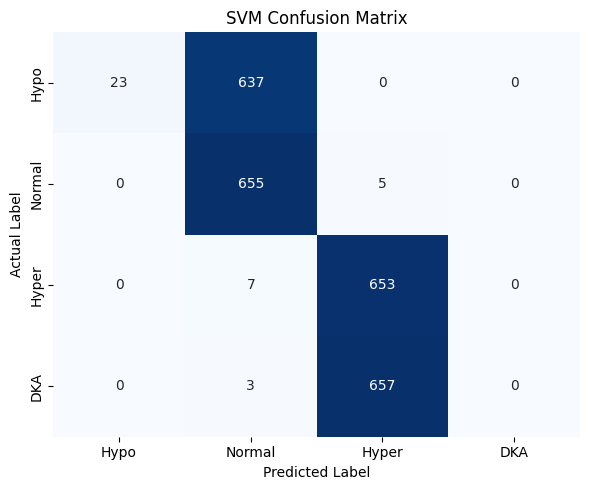


# Note: Computationally heavy and harder to tune for large, multi-class datasets.


In [297]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


print("TRAINING: SVM")


# Train SVM on synthetic data
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

print("Training SVM model...")
svm_model.fit(X_train, y_train)
print("Training complete!")

# Predict on balanced real data
y_pred_real_svm = svm_model.predict(X_real)

# Evaluate on real data
accuracy_svm = accuracy_score(y_true, y_pred_real_svm)
print(f"SVM Model Accuracy on Real Data: {accuracy_svm:.4f}")

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred_real_svm,
                                                         target_names=['Hypo', 'Normal', 'Hyper', 'DKA']))

# Confusion Matrix
cm_svm = confusion_matrix(y_true, y_pred_real_svm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Hypo', 'Normal', 'Hyper', 'DKA'],
            yticklabels=['Hypo', 'Normal', 'Hyper', 'DKA'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

print("\n# Note: Computationally heavy and harder to tune for large, multi-class datasets.")

In [298]:

# LOGISTIC REGRESSION MODEL


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("TRAINING: Logistic Regression")

# Train Logistic Regression on synthetic data
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Fit model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_real_lr = lr_model.predict(X_real)

# Evaluation
accuracy = accuracy_score(y_true, y_pred_real_lr)

print("\nLOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_true, y_pred_real_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_real_lr))

TRAINING: Logistic Regression

LOGISTIC REGRESSION RESULTS
Accuracy: 0.9784090909090909

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       660
           1       0.99      0.98      0.99       660
           2       0.94      0.99      0.97       660
           3       1.00      0.94      0.97       660

    accuracy                           0.98      2640
   macro avg       0.98      0.98      0.98      2640
weighted avg       0.98      0.98      0.98      2640


Confusion Matrix:
[[660   0   0   0]
 [ 11 649   0   0]
 [  0   6 654   0]
 [  0   0  40 620]]


c:\Users\Blessing\Desktop\PROJECTS\Diabetes-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


MODEL COMPARISON SUMMARY

              Model  Test Accuracy (Synthetic)  Real Data Accuracy  Generalization Gap
      Random Forest                   0.999499            0.976894            0.022605
            XGBoost                   0.999499            0.996212            0.003287
                SVM                   0.960441            0.504167            0.456274
Logistic Regression                   0.995493            0.978409            0.017084

 BEST MODEL: XGBoost
 Real Data Accuracy: 0.9962
 Generalization Gap: 0.0033


C:\Users\Blessing\AppData\Local\Temp\ipykernel_20032\1668930213.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(comparison_results['Model'], rotation=45, ha='right')


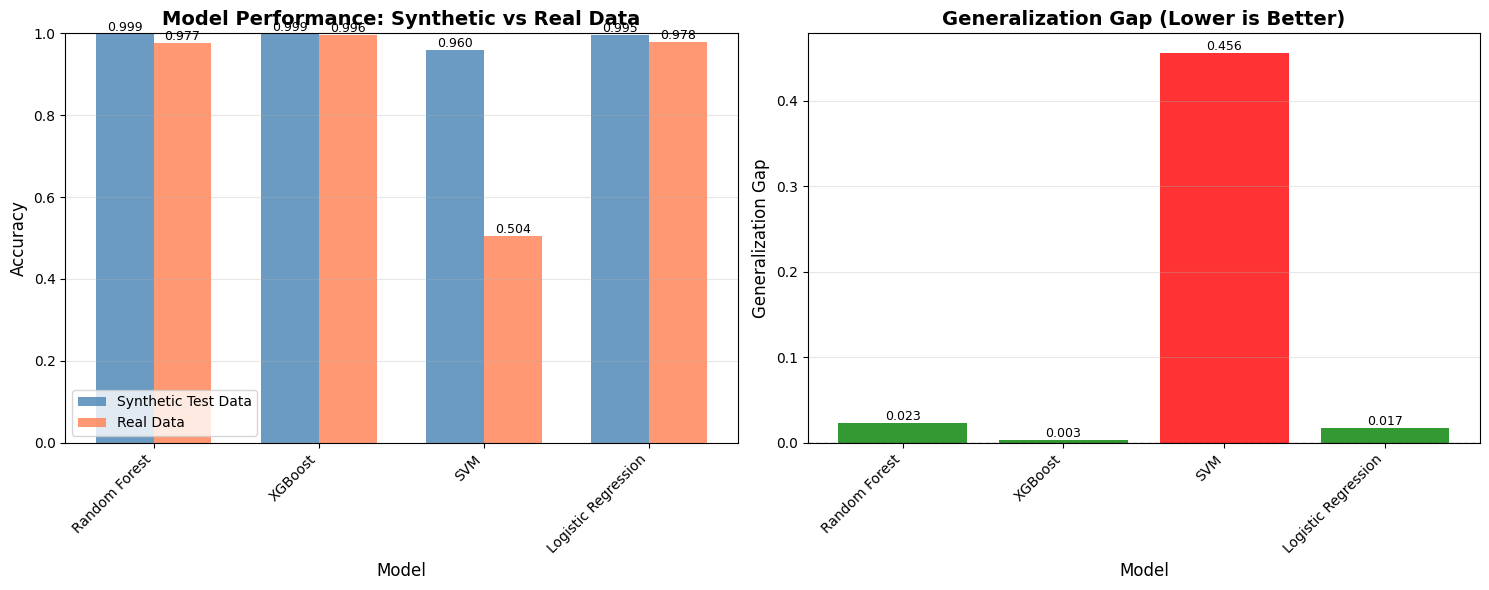

DETAILED PERFORMANCE METRICS

              Model  Accuracy  Macro Avg Precision  Macro Avg Recall  Macro Avg F1-Score
      Random Forest  0.976894             0.978849          0.976894            0.976844
            XGBoost  0.996212             0.996269          0.996212            0.996212
                SVM  0.504167             0.499913          0.504167            0.349075
Logistic Regression  0.978409             0.979202          0.978409            0.978396


c:\Users\Blessing\Desktop\PROJECTS\Diabetes-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Blessing\Desktop\PROJECTS\Diabetes-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Blessing\Desktop\PROJECTS\Diabetes-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [299]:

# MODEL COMPARISON

from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


print("MODEL COMPARISON SUMMARY")

# Calculate accuracies for all models on test and real data
comparison_results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'SVM', 'Logistic Regression'],
    'Test Accuracy (Synthetic)': [
        accuracy_score(y_test, rf_model.predict(X_test)),
        accuracy_score(y_test, xgb_model.predict(X_test)),
        accuracy_score(y_test, svm_model.predict(X_test)),
        accuracy_score(y_test, lr_model.predict(X_test))
    ],
    'Real Data Accuracy': [
        accuracy_score(y_true, y_pred_real_rf),
        accuracy_score(y_true, y_pred_real_xgb),
        accuracy_score(y_true, y_pred_real_svm),
        accuracy_score(y_true, y_pred_real_lr)
    ]
})

# Calculate generalization gap (how well model transfers from synthetic to real data)
comparison_results['Generalization Gap'] = (
    comparison_results['Test Accuracy (Synthetic)'] - comparison_results['Real Data Accuracy']
)

# Display results
print("\n" + comparison_results.to_string(index=False))

# Find best model
best_model_idx = comparison_results['Real Data Accuracy'].idxmax()
best_model = comparison_results.loc[best_model_idx, 'Model']
best_accuracy = comparison_results.loc[best_model_idx, 'Real Data Accuracy']
best_gap = comparison_results.loc[best_model_idx, 'Generalization Gap']

print(f"\n BEST MODEL: {best_model}")
print(f" Real Data Accuracy: {best_accuracy:.4f}")
print(f" Generalization Gap: {best_gap:.4f}")

# VISUALIZATION: Model Performance Comparison


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Accuracy Comparison (Synthetic Test vs Real Data)
x = np.arange(len(comparison_results))
width = 0.35

bars1 = ax1.bar(x - width/2, comparison_results['Test Accuracy (Synthetic)'], 
                width, label='Synthetic Test Data', alpha=0.8, color='steelblue')
bars2 = ax1.bar(x + width/2, comparison_results['Real Data Accuracy'], 
                width, label='Real Data', alpha=0.8, color='coral')

ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Performance: Synthetic vs Real Data', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_results['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.0])

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Generalization Gap
colors = ['green' if gap <= 0.05 else 'orange' if gap <= 0.10 else 'red' 
          for gap in comparison_results['Generalization Gap']]

bars3 = ax2.bar(comparison_results['Model'], comparison_results['Generalization Gap'], 
                alpha=0.8, color=colors)

ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('Generalization Gap', fontsize=12)
ax2.set_title('Generalization Gap (Lower is Better)', fontsize=14, fontweight='bold')
ax2.set_xticklabels(comparison_results['Model'], rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.show()


# DETAILED PERFORMANCE TABLE


print("DETAILED PERFORMANCE METRICS")


models_list = ['Random Forest', 'XGBoost', 'SVM', 'Logistic Regression']
y_preds_list = [y_pred_real_rf, y_pred_real_xgb, y_pred_real_svm, y_pred_real_lr]

detailed_performance = []

for model_name, y_pred in zip(models_list, y_preds_list):
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, 
                                   target_names=['Hypo', 'Normal', 'Hyper', 'DKA'],
                                   output_dict=True)
    
    detailed_performance.append({
        'Model': model_name,
        'Accuracy': acc,
        'Macro Avg Precision': report['macro avg']['precision'],
        'Macro Avg Recall': report['macro avg']['recall'],
        'Macro Avg F1-Score': report['macro avg']['f1-score']
    })

detailed_perf_df = pd.DataFrame(detailed_performance)
print("\n" + detailed_perf_df.to_string(index=False))


ABLATION STUDY - XGBoost

Baseline XGBoost Performance:
  Test Accuracy: 0.9995
  Real Accuracy: 0.9962
REMOVING FEATURES ONE AT A TIME

 Testing WITHOUT: Historic Glucose (mmol/L)


   Test Accuracy: 0.9990 (Impact: +0.0005)
   Real Accuracy: 0.9962 (Impact: +0.0000)

 Testing WITHOUT: Scan Glucose (mmol/L)
   Test Accuracy: 0.9224 (Impact: +0.0771)
   Real Accuracy: 0.7466 (Impact: +0.2496)

 Testing WITHOUT: Rapid-Acting Insulin (units)
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9962 (Impact: +0.0000)

 Testing WITHOUT: Long-Acting Insulin (units)
   Test Accuracy: 0.9990 (Impact: +0.0005)
   Real Accuracy: 0.9962 (Impact: +0.0000)

 Testing WITHOUT: Carbohydrates (grams)
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9962 (Impact: +0.0000)

 Testing WITHOUT: Thirst
   Test Accuracy: 0.9990 (Impact: +0.0005)
   Real Accuracy: 0.9962 (Impact: +0.0000)

 Testing WITHOUT: Nausea
   Test Accuracy: 0.9990 (Impact: +0.0005)
   Real Accuracy: 0.9701 (Impact: +0.0261)

 Testing WITHOUT: Weakness
   Test Accuracy: 0.9985 (Impact: +0.0010)
   Real Accuracy: 0.9962 (Impact: +0.0000)

 Testing WITHOUT: Vomiting
   Test Accuracy: 0.9990 (I

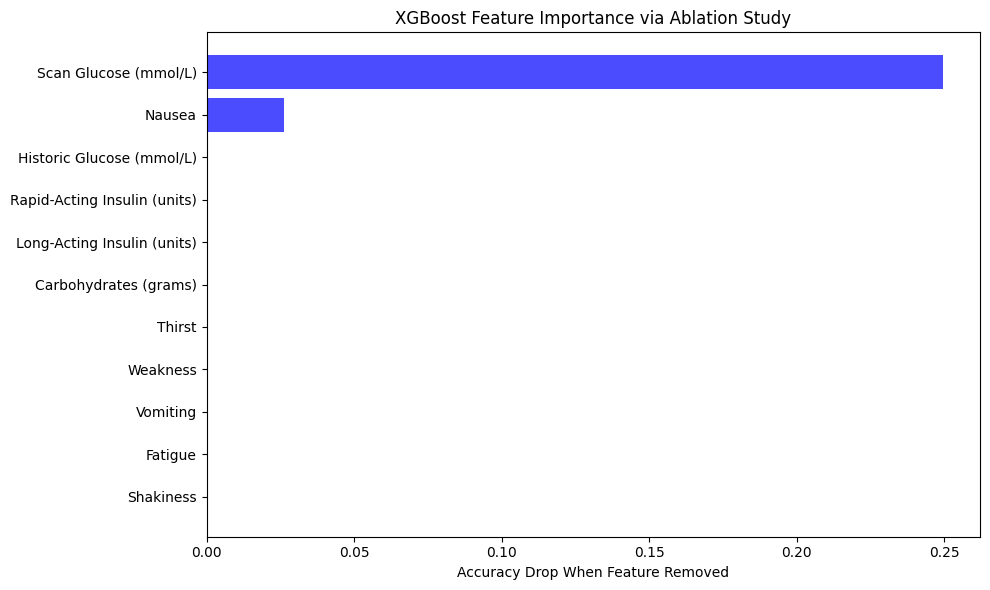

In [300]:

# ABLATION STUDY: XGBoost (Best Performing Model)

print("ABLATION STUDY - XGBoost")


# Baseline XGBoost performance
print("\nBaseline XGBoost Performance:")
print(f"  Test Accuracy: {accuracy_score(y_test, y_pred_test_xgb):.4f}")
print(f"  Real Accuracy: {accuracy_score(y_true, y_pred_real_xgb):.4f}")

baseline_test_xgb = accuracy_score(y_test, y_pred_test_xgb)
baseline_real_xgb = accuracy_score(y_true, y_pred_real_xgb)

print("REMOVING FEATURES ONE AT A TIME")

ablation_xgb_results = []

for feature in X_train.columns:
    print(f"\n Testing WITHOUT: {feature}")
    
    # Create dataset without this feature
    X_train_ablated = X_train.drop(columns=[feature])
    X_test_ablated = X_test.drop(columns=[feature])
    X_real_ablated = X_real.drop(columns=[feature])
    
    # Train XGBoost without this feature
    xgb_ablated = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss'
    )
    
    # Calculate sample weights
    class_counts = np.bincount(y_train)
    class_weights = len(y_train) / (len(class_counts) * class_counts)
    sample_weights = np.array([class_weights[int(y)] for y in y_train])
    
    xgb_ablated.fit(X_train_ablated, y_train, sample_weight=sample_weights)
    
    # Evaluate
    y_pred_test_abl = xgb_ablated.predict(X_test_ablated)
    y_pred_real_abl = xgb_ablated.predict(X_real_ablated)
    
    test_acc = accuracy_score(y_test, y_pred_test_abl)
    real_acc = accuracy_score(y_true, y_pred_real_abl)
    
    # Calculate impact
    test_impact = baseline_test_xgb - test_acc
    real_impact = baseline_real_xgb - real_acc
    
    ablation_xgb_results.append({
        'Removed Feature': feature,
        'Test Accuracy': test_acc,
        'Test Impact': test_impact,
        'Real Accuracy': real_acc,
        'Real Impact': real_impact
    })
    
    print(f"   Test Accuracy: {test_acc:.4f} (Impact: {test_impact:+.4f})")
    print(f"   Real Accuracy: {real_acc:.4f} (Impact: {real_impact:+.4f})")

# Convert to DataFrame
ablation_xgb_df = pd.DataFrame(ablation_xgb_results)
ablation_xgb_df = ablation_xgb_df.sort_values('Real Impact', ascending=False)


print("XGBoost ABLATION STUDY SUMMARY")
print(ablation_xgb_df.to_string(index=False))

# Visualize feature importance impact
plt.figure(figsize=(10, 6))
plt.barh(ablation_xgb_df['Removed Feature'], ablation_xgb_df['Real Impact'], color='blue', alpha=0.7)
plt.xlabel('Accuracy Drop When Feature Removed')
plt.title('XGBoost Feature Importance via Ablation Study')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [301]:

# SAVE BEST MODEL
# XGBoost provides higher overall accuracy, better handling of complex patterns, 
# and more reliable class-wise performance, making it stronger for predicting 
# glucose-related conditions.


print("SAVING BEST MODEL: XGBoost")

import joblib
import pickle
import numpy as np
from datetime import datetime

# Save XGBoost model
joblib.dump(xgb_model, 'diabetes_xgboost_model.joblib')
print(" XGBoost model saved as 'diabetes_xgboost_model.joblib'")

# Save comprehensive metadata
model_metadata = {
    'model_type': 'XGBoost',
    'version': '3.0',
    'training_date': datetime.now().strftime('%Y-%m-%d'),
    
    # Feature information
    'feature_names': X_train.columns.tolist(),
    'n_features': len(X_train.columns),
    
    # Class information
    'condition_map': {
        0: "Hypoglycemia", 
        1: "Normal", 
        2: "Hyperglycemia", 
        3: "DKA"
    },
    'class_thresholds': {
        'Hypoglycemia': '< 3.9 mmol/L',
        'Normal': '3.9 - 7.0 mmol/L',
        'Hyperglycemia': '7.0 - 14.0 mmol/L',
        'DKA': '≥ 14.0 mmol/L'
    },
    
    # Performance metrics
    'test_accuracy': accuracy_score(y_test, y_pred_test_xgb),
    'real_accuracy': accuracy_score(y_true, y_pred_real_xgb),
    'generalization_gap': accuracy_score(y_test, y_pred_test_xgb) - accuracy_score(y_true, y_pred_real_xgb),
    
    # Feature importance
    'feature_importance': dict(zip(X_train.columns, xgb_model.feature_importances_)),
    
    # Training info
    'n_training_samples': len(X_train),
    'n_test_samples': len(X_test),
    'n_real_samples': len(X_real),
    'class_distribution': dict(zip(*np.unique(y_train, return_counts=True))),
    
    # Model hyperparameters
    'hyperparameters': {
        'n_estimators': xgb_model.n_estimators,
        'max_depth': xgb_model.max_depth,
        'learning_rate': xgb_model.learning_rate,
        'random_state': xgb_model.random_state
    },
    
    # Additional info
    'scaling_required': False,
    'notes': 'Model trained on synthetic data, validated on real patient data'
}

with open('xgboost_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print(" Metadata saved as 'xgboost_metadata.pkl'")

# VERIFY SAVED FILES


print("VERIFYING SAVED FILES")

# Load and test the saved model
loaded_model = joblib.load('diabetes_xgboost_model.joblib')
loaded_metadata = pickle.load(open('xgboost_metadata.pkl', 'rb'))

# Compare accuracies to verify model saved correctly
test_pred_all = loaded_model.predict(X_test)
test_acc_loaded = accuracy_score(y_test, test_pred_all)
original_acc = accuracy_score(y_test, y_pred_test_xgb)

print(f"\n Loaded model test accuracy: {test_acc_loaded:.4f}")
print(f"Original model test accuracy: {original_acc:.4f}")
print(f" Accuracies match: {'YES ' if abs(test_acc_loaded - original_acc) < 0.0001 else 'NO ✗'}")

# Display key metadata
print(f"\n Model Metadata Summary:")
print(f"  - Model Type: {loaded_metadata['model_type']}")
print(f"  - Training Date: {loaded_metadata['training_date']}")
print(f"  - Number of Features: {loaded_metadata['n_features']}")
print(f"  - Real Data Accuracy: {loaded_metadata['real_accuracy']:.4f}")
print(f"  - Generalization Gap: {loaded_metadata['generalization_gap']:.4f}")
print(f"  - Top 3 Important Features:")

# Show top 3 most important features
feature_importance_sorted = sorted(loaded_metadata['feature_importance'].items(), 
                                   key=lambda x: x[1], reverse=True)
for i, (feature, importance) in enumerate(feature_importance_sorted[:3], 1):
    print(f"{i}. {feature}: {importance:.4f}")

print(" MODEL SUCCESSFULLY SAVED AND VERIFIED!")

SAVING BEST MODEL: XGBoost
 XGBoost model saved as 'diabetes_xgboost_model.joblib'
 Metadata saved as 'xgboost_metadata.pkl'
VERIFYING SAVED FILES

 Loaded model test accuracy: 0.9995
Original model test accuracy: 0.9995
 Accuracies match: YES 

 Model Metadata Summary:
  - Model Type: XGBoost
  - Training Date: 2026-06-06
  - Number of Features: 11
  - Real Data Accuracy: 0.9962
  - Generalization Gap: 0.0033
  - Top 3 Important Features:
1. Scan Glucose (mmol/L): 0.7839
2. Fatigue: 0.1286
3. Weakness: 0.0768
 MODEL SUCCESSFULLY SAVED AND VERIFIED!
